# ***Installing & Importing Libraries***

In [ ]:
!pip install pandas numpy matplotlib seaborn plotly -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print('All libraries imported successfully!')

All libraries imported successfully!


# ***Uploading and Loading Data***

In [ ]:
from google.colab import files
import io

uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f'Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns')
df.head(10)

Saving hospital_patient_treatment_dataset.csv to hospital_patient_treatment_dataset.csv
Dataset loaded: 200 rows x 9 columns


,Patient ID,Department,Treatment Type,Doctor Name,Gender,Age,Treatment Cost,Hospital Stay (Days),Recovery Score
0,P1001,Gastroenterology,Therapy,Dr. L. Khan,Female,12,68632.97,21,82
1,P1002,Pediatrics,Medication,Dr. M. Patel,Male,52,10231.42,20,42
2,P1003,Pediatrics,Therapy,Dr. L. Khan,Male,79,10160.24,2,72
3,P1004,Pediatrics,Therapy,Dr. L. Khan,Female,23,103508.96,20,50
4,P1005,Orthopedics,Medication,Dr. T. Mehta,Female,7,143427.52,6,43
5,P1006,Cardiology,Medication,Dr. A. Sharma,Female,78,146252.19,9,41
6,P1007,Cardiology,Observation,Dr. M. Patel,Other,30,54393.48,1,42
7,P1008,Neurology,Observation,Dr. R. Singh,Other,68,30452.22,6,77
8,P1009,Gastroenterology,Observation,Dr. L. Khan,Other,41,79517.25,9,62
9,P1010,Pediatrics,Medication,Dr. T. Mehta,Other,56,116558.38,24,48


# ***Inspecting the Data***

In [ ]:
print('Shape:', df.shape)
print('\nData Types:')
print(df.dtypes)
print('\nMissing Values:')
print(df.isnull().sum())
print('\nDuplicates:', df.duplicated().sum())
print('\nStatistical Summary:')
df.describe().round(2)

Shape: (200, 9)

Data Types:
Patient ID               object
Department               object
Treatment Type           object
Doctor Name              object
Gender                   object
Age                       int64
Treatment Cost          float64
Hospital Stay (Days)      int64
Recovery Score            int64
dtype: object

Missing Values:
Patient ID              0
Department              0
Treatment Type          0
Doctor Name             0
Gender                  0
Age                     0
Treatment Cost          0
Hospital Stay (Days)    0
Recovery Score          0
dtype: int64

Duplicates: 0

Statistical Summary:


,Age,Treatment Cost,Hospital Stay (Days),Recovery Score
count,200.00,200.00,200.00,200.00
mean,41.71,79698.51,16.02,70.38
std,26.14,43406.74,9.11,17.73
min,1.00,5444.80,1.00,40.00
25%,19.00,45451.88,7.00,55.00
50%,40.00,79268.87,17.00,72.00
75%,62.25,118701.90,24.00,85.00
max,90.00,149340.16,30.00,100.00


# ***Cleaning Data & Creating New Coloumns***

In [ ]:
str_cols = df.select_dtypes(include='object').columns
df[str_cols] = df[str_cols].apply(lambda x: x.str.strip())
df.columns = df.columns.str.strip()

df['Age Group'] = pd.cut(df['Age'],
    bins=[0,12,17,35,60,100],
    labels=['Child (0-12)','Teen (13-17)',
            'Young Adult (18-35)','Adult (36-60)','Senior (61+)'])

df['Cost Category'] = pd.cut(df['Treatment Cost'],
    bins=[0,40000,80000,120000,160000],
    labels=['Low','Medium','High','Very High'])

df['Recovery Category'] = pd.cut(df['Recovery Score'],
    bins=[0,55,75,100],
    labels=['Poor','Moderate','Good'])

print('Cleaning done! New shape:', df.shape)
df.head()

Cleaning done! New shape: (200, 12)


,Patient ID,Department,Treatment Type,Doctor Name,Gender,Age,Treatment Cost,Hospital Stay (Days),Recovery Score,Age Group,Cost Category,Recovery Category
0,P1001,Gastroenterology,Therapy,Dr. L. Khan,Female,12,68632.97,21,82,Child (0-12),Medium,Good
1,P1002,Pediatrics,Medication,Dr. M. Patel,Male,52,10231.42,20,42,Adult (36-60),Low,Poor
2,P1003,Pediatrics,Therapy,Dr. L. Khan,Male,79,10160.24,2,72,Senior (61+),Low,Moderate
3,P1004,Pediatrics,Therapy,Dr. L. Khan,Female,23,103508.96,20,50,Young Adult (18-35),High,Poor
4,P1005,Orthopedics,Medication,Dr. T. Mehta,Female,7,143427.52,6,43,Child (0-12),Very High,Poor


# ***Department & Treatment Charts***

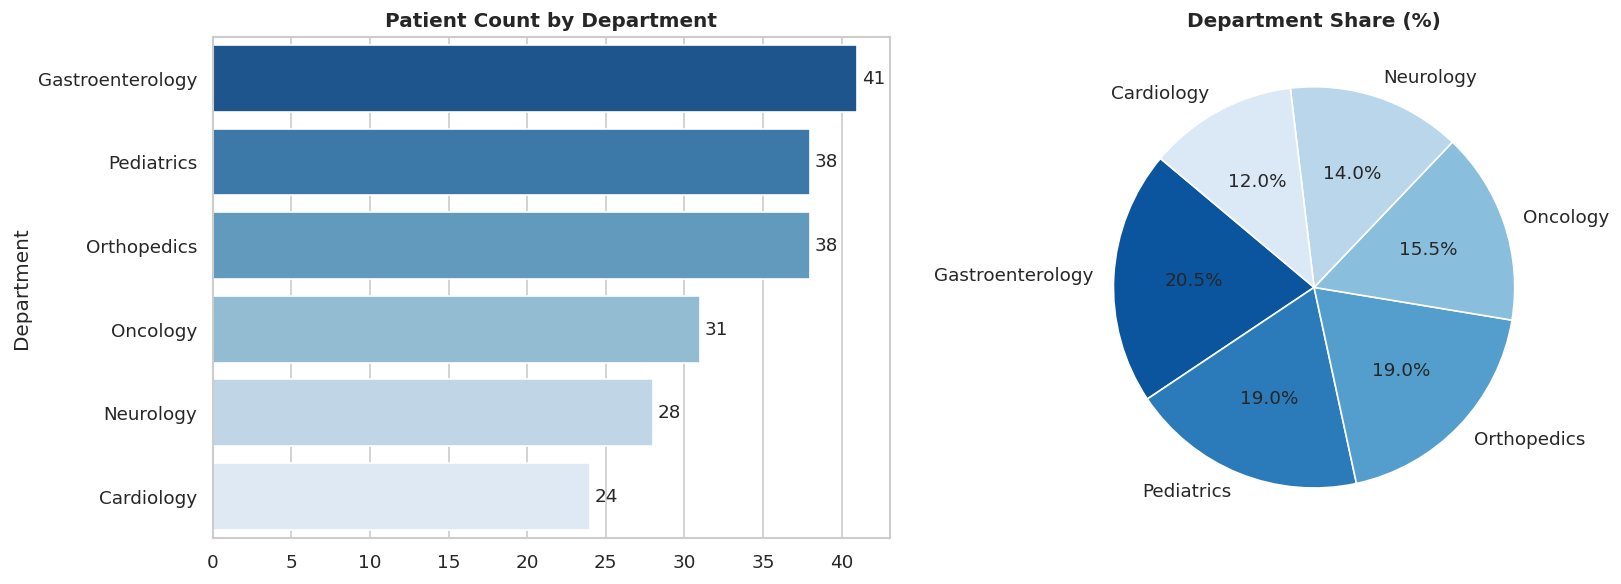

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
dept_counts = df['Department'].value_counts()

sns.barplot(x=dept_counts.values, y=dept_counts.index, palette='Blues_r', ax=axes[0])
axes[0].set_title('Patient Count by Department', fontweight='bold')
for i, v in enumerate(dept_counts.values):
    axes[0].text(v+0.3, i, str(v), va='center')

axes[1].pie(dept_counts.values, labels=dept_counts.index,
            autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('Blues_r', len(dept_counts)))
axes[1].set_title('Department Share (%)', fontweight='bold')
plt.tight_layout()
plt.savefig('chart_department.png', bbox_inches='tight')
plt.show()

# ***Treatment Cost Analysis***

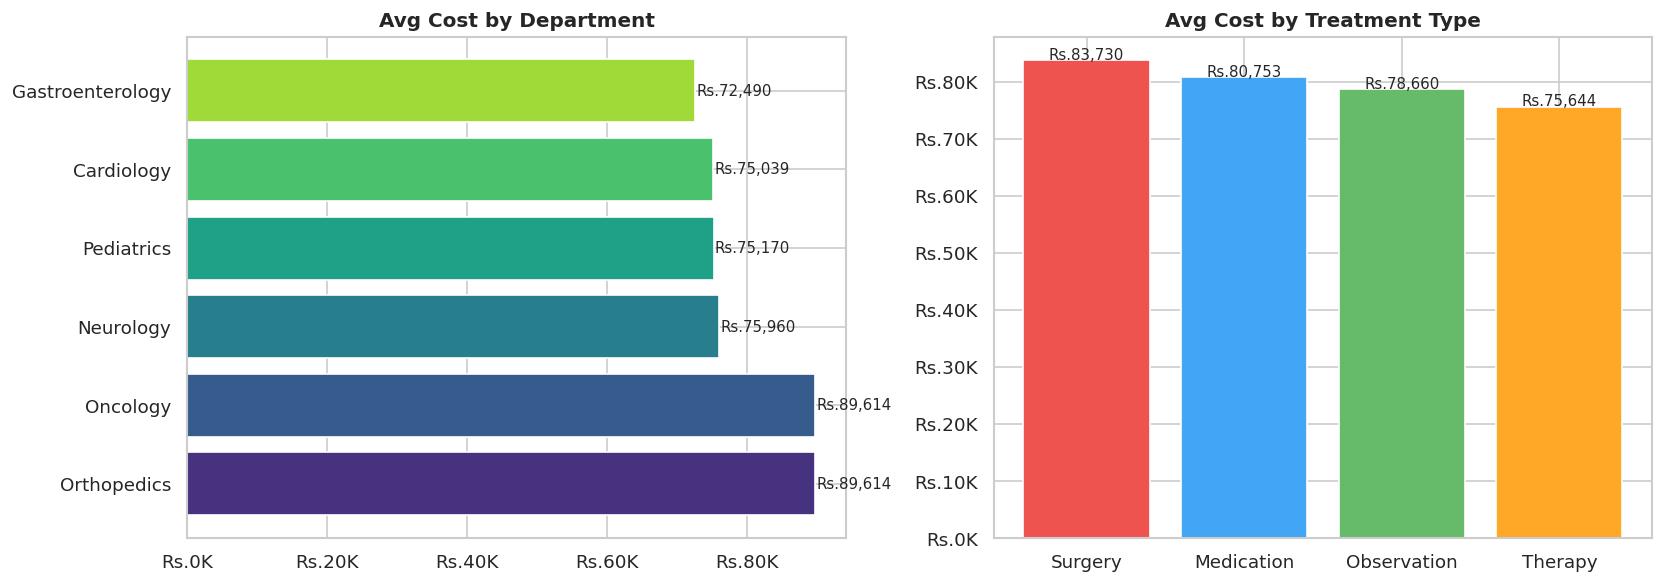

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

avg_cost = df.groupby('Department')['Treatment Cost'].mean().sort_values(ascending=False)
axes[0].barh(avg_cost.index, avg_cost.values,
             color=sns.color_palette('viridis', len(avg_cost)))
axes[0].set_title('Avg Cost by Department', fontweight='bold')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'Rs.{x/1000:.0f}K'))
for i, v in enumerate(avg_cost.values):
    axes[0].text(v+200, i, f'Rs.{v:,.0f}', va='center', fontsize=9)

avg_cost_t = df.groupby('Treatment Type')['Treatment Cost'].mean().sort_values(ascending=False)
axes[1].bar(avg_cost_t.index, avg_cost_t.values,
            color=['#EF5350','#42A5F5','#66BB6A','#FFA726'])
axes[1].set_title('Avg Cost by Treatment Type', fontweight='bold')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'Rs.{x/1000:.0f}K'))
for i, v in enumerate(avg_cost_t.values):
    axes[1].text(i, v+200, f'Rs.{v:,.0f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('chart_cost.png', bbox_inches='tight')
plt.show()

# ***Recovery Score & Doctor Performance***

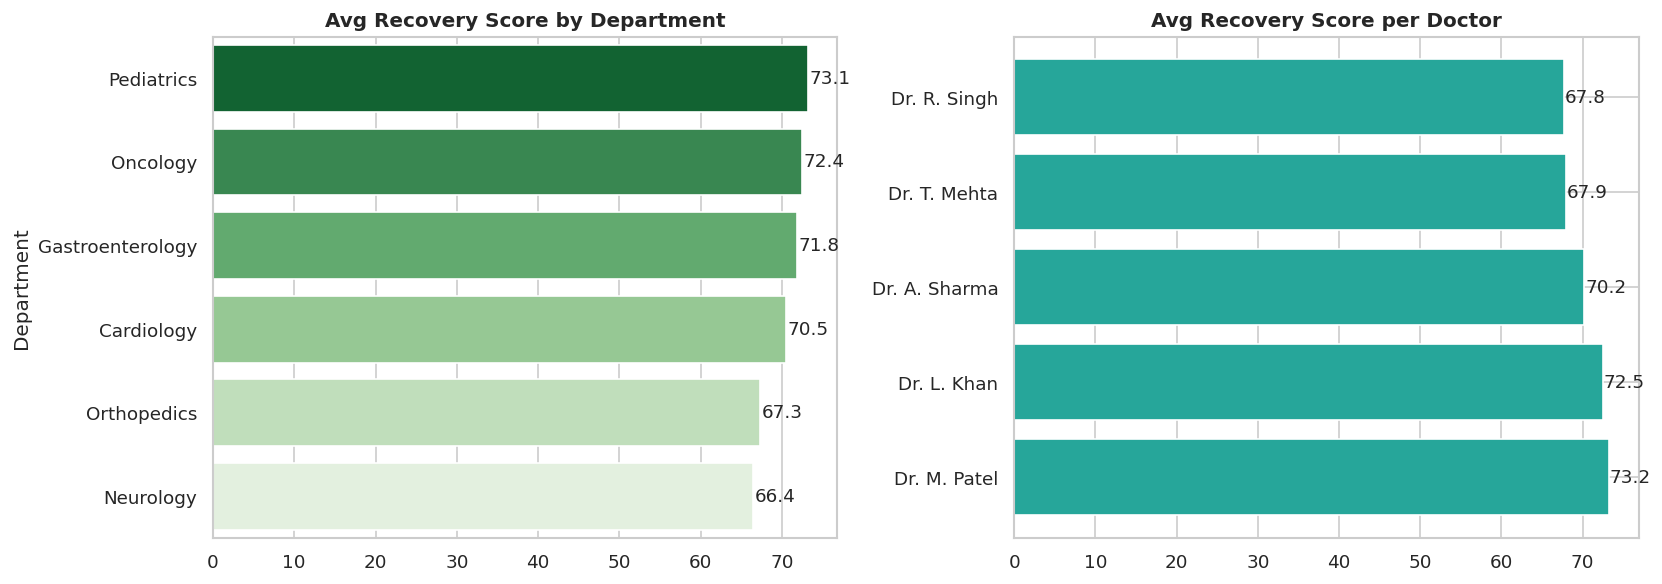

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

avg_rec = df.groupby('Department')['Recovery Score'].mean().sort_values(ascending=False)
sns.barplot(x=avg_rec.values, y=avg_rec.index, palette='Greens_r', ax=axes[0])
axes[0].set_title('Avg Recovery Score by Department', fontweight='bold')
for i, v in enumerate(avg_rec.values):
    axes[0].text(v+0.2, i, f'{v:.1f}', va='center')

doc_rec = df.groupby('Doctor Name')['Recovery Score'].mean().sort_values(ascending=False)
axes[1].barh(doc_rec.index, doc_rec.values, color='#26A69A')
axes[1].set_title('Avg Recovery Score per Doctor', fontweight='bold')
for i, v in enumerate(doc_rec.values):
    axes[1].text(v+0.1, i, f'{v:.1f}', va='center')
plt.tight_layout()
plt.savefig('chart_recovery.png', bbox_inches='tight')
plt.show()

# ***Correlation Heatmap***

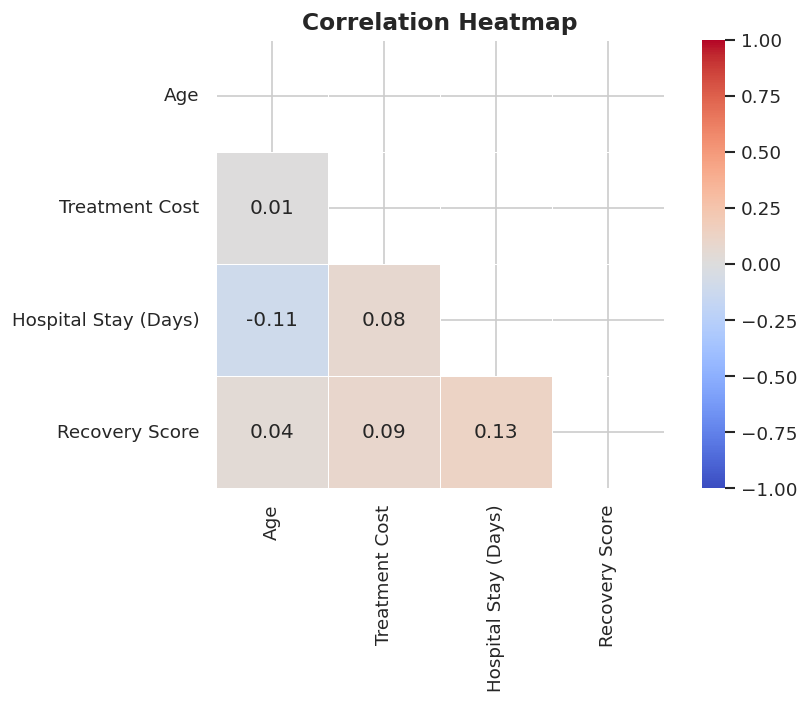

In [ ]:
plt.figure(figsize=(8, 6))
num_cols = ['Age', 'Treatment Cost', 'Hospital Stay (Days)', 'Recovery Score']
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, square=True,
            linewidths=0.5, annot_kws={'size': 12})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_correlation.png', bbox_inches='tight')
plt.show()

# ***Key Insight Summary***

In [ ]:
print('='*55)
print('   KEY BUSINESS INSIGHTS')
print('='*55)
print(f'Total Patients       : {len(df)}')
print(f'Average Age          : {df["Age"].mean():.1f} years')
print(f'Avg Treatment Cost   : Rs.{df["Treatment Cost"].mean():,.0f}')
print(f'Avg Hospital Stay    : {df["Hospital Stay (Days)"].mean():.1f} days')
print(f'Avg Recovery Score   : {df["Recovery Score"].mean():.1f}/100')
print()
top_dept = df['Department'].value_counts().index[0]
print(f'Most Patients Dept   : {top_dept}')
best_rec = df.groupby("Department")["Recovery Score"].mean().idxmax()
print(f'Best Recovery Dept   : {best_rec}')
best_doc = df.groupby("Doctor Name")["Recovery Score"].mean().idxmax()
print(f'Top Recovery Doctor  : {best_doc}')
best_treat = df.groupby("Treatment Type")["Recovery Score"].mean().idxmax()
print(f'Best Treatment Type  : {best_treat}')
good_pct = (df['Recovery Category']=='Good').mean()*100
print(f'Patients - Good Recovery: {good_pct:.1f}%')
print('='*55)

   KEY BUSINESS INSIGHTS
Total Patients       : 200
Average Age          : 41.7 years
Avg Treatment Cost   : Rs.79,699
Avg Hospital Stay    : 16.0 days
Avg Recovery Score   : 70.4/100

Most Patients Dept   : Gastroenterology
Best Recovery Dept   : Pediatrics
Top Recovery Doctor  : Dr. M. Patel
Best Treatment Type  : Surgery
Patients - Good Recovery: 43.5%


In [ ]:
df.to_csv('hospital_cleaned.csv', index=False)
print('Cleaned file saved!')

from google.colab import files
files.download('hospital_cleaned.csv')
print('File downloaded to your computer - ready for Phase 2!')

Cleaned file saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

File downloaded to your computer - ready for Phase 2!
